In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
import yfinance as yf

# Download 5 years of Apple stock data
df_stock = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
df = df_stock[['Close']]
df.columns = ['Close']

print(df.head())

/tmp/ipykernel_8753/419921087.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_stock = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

                Close
Date                 
2019-01-02  37.503719
2019-01-03  33.768085
2019-01-04  35.209614
2019-01-07  35.131256
2019-01-08  35.800945


In [3]:
print(df.info())
print("=" * 10)
print(df.shape)
print("=" * 10)
print(df.isna().sum())

# Pandas has set the Date as DatetimeIndex

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1258 non-null   float64
dtypes: float64(1)
memory usage: 19.7 KB
None
(1258, 1)
Close    0
dtype: int64


## Convert to float and change the dim to 2D Numpy arr

In [4]:
df = df['Close'].values.astype(float).reshape(-1, 1)

## Train-Test split and Sequencing

In [5]:
# MUST KEEP THE SEQUENCE => the whole point of time-series dataset and DL
train_data, test_data = train_test_split(df, test_size=0.2, shuffle=False)

## Normalization using MinMaxScaler

In [6]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data)
train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(test_data)

In [7]:
"""
Sequence helps the model to not forget about the previous data:
The Input (X): The number of passengers from January to December.
The Output (y): The predicted number of passengers for the next January.

Think of it like teaching a human to recognize a song.
If you play just one note, they can't guess the song.
If you play a sequence of 5 notes, they have a chance.
"""

def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i : i + window]) # The sequence
        y.append(data[i + window])     # The next value
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, window=30)
X_test, y_test = create_sequences(test_scaled, window=30)

print(X_train)

[[[0.02588158]
  [0.        ]
  [0.00998734]
  ...
  [0.04601539]
  [0.04842805]
  [0.04725482]]

 [[0.        ]
  [0.00998734]
  [0.00944445]
  ...
  [0.04842805]
  [0.04725482]
  [0.04827928]]

 [[0.00998734]
  [0.00944445]
  [0.01408426]
  ...
  [0.04725482]
  [0.04827928]
  [0.04765131]]

 ...

 [[0.76754364]
  [0.7868413 ]
  [0.77715833]
  ...
  [0.66819156]
  [0.68967123]
  [0.66771414]]

 [[0.7868413 ]
  [0.77715833]
  [0.78915969]
  ...
  [0.68967123]
  [0.66771414]
  [0.66519109]]

 [[0.77715833]
  [0.78915969]
  [0.78063601]
  ...
  [0.66771414]
  [0.66519109]
  [0.65271247]]]


In [8]:
# Convert to tensor
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

## GRU Model

In [9]:
class GRUModel(nn.Module):
    """
      args explain:
      input_dim: number of input features
      hidden_dim: number of neurons in LSTM
      layer_dim: number of LSTM layers being stacked
      output_dim: number of output features
    """

    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.gru = nn.GRU(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None):
      # GRU only has a hidden state (h0). There is no cell state (c0)!
        if h0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        # The forward pass returns the output and only ONE state (hn)
        out, hn = self.gru(x, h0)

        # We still take the last "thought" from the sequence
        out = self.fc(out[:, -1, :])

        return out, hn

In [10]:
model = GRUModel(input_dim=1, hidden_dim=128, layer_dim=1, output_dim=1)
criterion = nn.MSELoss()  # Mean Squared Error for Regression (this depends on my task, if classi => use CrossEntropyLoss)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [11]:
num_epochs = 100
# Here we dont want to Statefully Train because its not a loop
# for the sine wave, the pattern repeat while if we keeping this then the model might understand that 1960 is the previous step of 1949
# since the data state isn't be wiped off before starting a new epoch

for epoch in range(num_epochs):
    model.train()

    # 1. Clear gradients from the previous lap
    optimizer.zero_grad()

    # 2. Forward pass
    # Passing None for states tells your model to start with a blank memory (zeros)
    # We use _ for the states because we don't need to save them for the next epoch
    # Only two here since GRU combined the cell states and hidden states
    outputs, _ = model(X_train_tensor, h0=None)

    # 3. Calculate Loss
    loss = criterion(outputs, y_train_tensor)

    # 4. Backpropagation (Calculate gradients)
    loss.backward()

    # 5. Update Weights
    optimizer.step()

    # Logging every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.0822
Epoch [20/100], Loss: 0.0297
Epoch [30/100], Loss: 0.0049
Epoch [40/100], Loss: 0.0010
Epoch [50/100], Loss: 0.0009
Epoch [60/100], Loss: 0.0006
Epoch [70/100], Loss: 0.0003
Epoch [80/100], Loss: 0.0003
Epoch [90/100], Loss: 0.0003
Epoch [100/100], Loss: 0.0003


## Evaluation

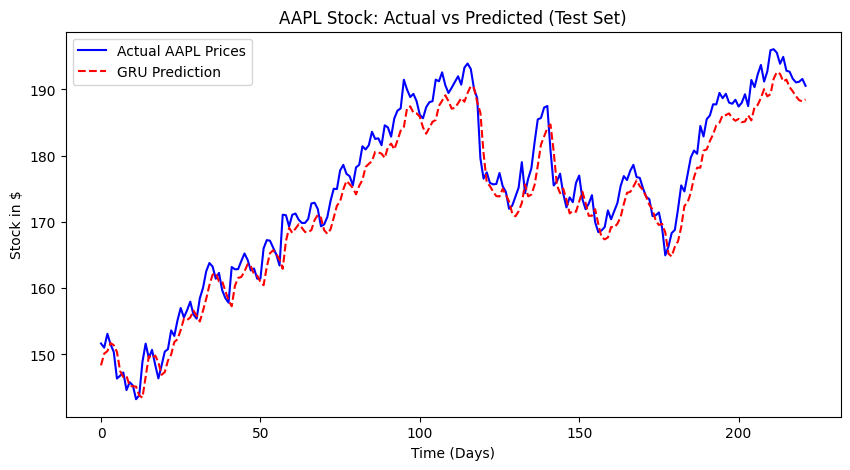

The average error is: $3.11


In [12]:
# 1. Set model to evaluation mode
model.eval()

# 2. Turn off gradient calculation (saves memory/time)
with torch.no_grad():
    # We only need the first output (predictions)
    # Only 2, no cell state here
    test_predict, _ = model(X_test_tensor)

# 3. Convert tensors back to NumPy arrays
test_predict = test_predict.numpy()
y_test_actual = y_test_tensor.numpy()

# 4. Invert the scaling
test_predict_orig = scaler.inverse_transform(test_predict)
y_test_actual_orig = scaler.inverse_transform(y_test_actual)

# 5. Create the plot
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual_orig, label='Actual AAPL Prices', color='blue')
plt.plot(test_predict_orig, label='GRU Prediction', color='red', linestyle='--')

plt.title('AAPL Stock: Actual vs Predicted (Test Set)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock in $')
plt.legend()
plt.show()

from sklearn.metrics import mean_squared_error

# Calculate the error in actual dollars
rmse = np.sqrt(mean_squared_error(y_test_actual_orig, test_predict_orig))
print(f"The average error is: ${rmse:.2f}")

## Single Prediction

In [13]:
# 1. Pick the last 30 days (trading days) from your dataset
# Use test_scaled (or data_scaled) depending on your variable name
last_window = test_scaled[-30:]

# 2. Reshape and convert to a PyTorch tensor
# Shape: (1 sample, 30 days of history, 1 feature)
input_tensor = torch.from_numpy(last_window).float().view(1, 30, 1)

# 3. Put the model in evaluation mode and predict
model.eval()
with torch.no_grad():
    # FIXED: Only unpack TWO values for GRU (prediction and hidden state)
    prediction_scaled, _ = model(input_tensor)

# 4. Convert the scaled result back to real dollars
# We convert the tensor to numpy first
prediction_actual = scaler.inverse_transform(prediction_scaled.numpy())

# Since your dataset ends on 2023-12-29, this is Jan 2nd, 2024
print(f"The predicted AAPL Stock Price for the next trading day is: ${prediction_actual[0][0]:.2f}")

The predicted AAPL Stock Price for the next trading day is: $187.97
